In [9]:
import sys
import os
import importlib

parent = os.path.dirname(os.getcwd())
sys.path.insert(0, parent)

from Helpers import loadData, multiplot, sphereMask, saveData, chunker, unchunker, kernelPad
importlib.reload(sys.modules['Helpers.chunker'])
importlib.reload(sys.modules['Helpers.unchunker'])
importlib.reload(sys.modules['Helpers.kernelPad'])
importlib.reload(sys.modules['Helpers'])

import h5py
import matplotlib.pyplot as plt
import numpy as np
import stackview
from scipy.ndimage import zoom

In [11]:
path = r'C:\Users\Lab User\Desktop\ModernExperiments\exp_118\Scan_3.hdf5'
with h5py.File(path,"r") as f:
    print(list(f['RawData'].keys()))
    data = f['RawData']['Scan_3'][()]
    sz = np.shape(data)
    print(sz)

['Scan_3']
(500, 1224, 1024)


In [12]:
zData = zoom(data,.25)
print(np.shape(zData))

(125, 306, 256)


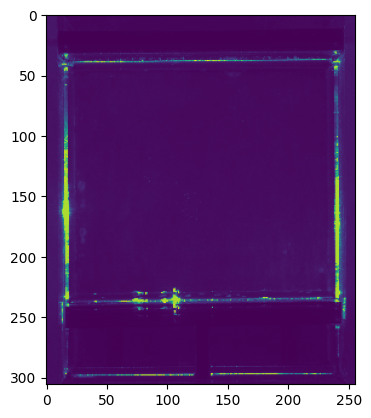

In [18]:
plt.imshow(zData[10,:,:])

In [13]:
stackview.orthogonal(zData, continuous_update=True)

In [ ]:
fig, axs = plt.subplots(1,3)
axs[0].imshow(data[sz[0]//2,:,:]); axs[0].axis('off')
axs[1].imshow(data[:,sz[1]//2,:]); axs[1].axis('off')
axs[2].imshow(data[:,:,sz[2]//2]); axs[2].axis('off')
fig.set_size_inches(12,12)

In [ ]:
p=200
fig, axs = plt.subplots(1,3)
axs[0].imshow(data[p,:,:]); axs[0].axis('off')
axs[1].imshow(data[:,p,:]); axs[1].axis('off')
axs[2].imshow(data[:,:,p]); axs[2].axis('off')
fig.set_size_inches(12,12)

In [ ]:
p=200
fig,axs=plt.subplots(1,5)
for i in range(len(axs)):
    axs[i].imshow(data[p+i,:,:]); axs[i].axis('off')
fig.set_size_inches(20,15)

In [ ]:
p=200
fig,axs=plt.subplots(1,5)
for i in range(len(axs)):
    axs[i].imshow(data[:,p+i,:]); axs[i].axis('off')
fig.set_size_inches(20,15)

In [ ]:
p=200
fig,axs=plt.subplots(1,5)
for i in range(len(axs)):
    axs[i].imshow(data[:,:,p+i]); axs[i].axis('off')
fig.set_size_inches(20,15)

In [ ]:
edge_positions = np.argmax(data[:, :, :].max(axis=1), axis=1)
plt.plot(edge_positions)
plt.xlabel('Frame (Z)')
plt.ylabel('X position of bright edge')

In [ ]:
from skimage.registration import phase_cross_correlation

# Align each frame to the first frame
reference = data[0]
aligned = np.zeros_like(data)
aligned[0] = reference

for i in range(1, data.shape[0]):
    shift, _, _ = phase_cross_correlation(reference, data[i])
    aligned[i] = np.roll(data[i], shift.astype(int), axis=(0,1))

In [ ]:
plt.imshow(aligned[:,200,:])

In [ ]:
dog = f1['RawData']

In [ ]:
type(dog)

In [ ]:
meow = np.array(dog)

In [ ]:
meow.shape

In [ ]:
path = r'C:\Users\Lab User\Desktop\temp1\Granular-Compression\Data\Scan_1.hdf5'

with h5py.File(f'{path}','r') as f:
    data = f['/RawData'][()]

In [ ]:
data

In [ ]:
plt.imshow(data[:,:,data.shape])